<a href="https://colab.research.google.com/github/shagun53/brain-tumor-cnn-classifier/blob/main/Brain_Tumor_Detection_Using_CNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
!pip install tensorflow

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [41]:
import zipfile

with zipfile.ZipFile('/content/brain_tumor_dataset.zip', 'r') as z:
    z.extractall('/content/brain_tumor_dataset')

In [42]:
import os
for root, dirs, files_list in os.walk('/content/brain_tumor_dataset'):
    for d in dirs:
        path = os.path.join(root, d)
        count = len(os.listdir(path))
        print(f'{path}: {count} images')

/content/brain_tumor_dataset/no: 98 images
/content/brain_tumor_dataset/yes: 155 images
/content/brain_tumor_dataset/brain_tumor_dataset: 2 images
/content/brain_tumor_dataset/brain_tumor_dataset/no: 98 images
/content/brain_tumor_dataset/brain_tumor_dataset/yes: 155 images


In [43]:
!find /content/brain_tumor_dataset -maxdepth 2 -type d

/content/brain_tumor_dataset
/content/brain_tumor_dataset/no
/content/brain_tumor_dataset/yes
/content/brain_tumor_dataset/brain_tumor_dataset
/content/brain_tumor_dataset/brain_tumor_dataset/no
/content/brain_tumor_dataset/brain_tumor_dataset/yes


In [44]:
import shutil

shutil.rmtree('/content/brain_tumor_dataset/brain_tumor_dataset')

In [45]:
!find /content/brain_tumor_dataset -maxdepth 2 -type d

/content/brain_tumor_dataset
/content/brain_tumor_dataset/no
/content/brain_tumor_dataset/yes


In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

training_set = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [47]:
!find /content/brain_tumor_dataset -type f | head

/content/brain_tumor_dataset/no/no 99.jpg
/content/brain_tumor_dataset/no/29 no.jpg
/content/brain_tumor_dataset/no/20 no.jpg
/content/brain_tumor_dataset/no/N17.jpg
/content/brain_tumor_dataset/no/39 no.jpg
/content/brain_tumor_dataset/no/No15.jpg
/content/brain_tumor_dataset/no/15 no.jpg
/content/brain_tumor_dataset/no/8 no.jpg
/content/brain_tumor_dataset/no/no 923.jpg
/content/brain_tumor_dataset/no/no 4.jpg


In [48]:
print(training_set.class_indices)
print("Training images:", training_set.samples)
print("Validation images:", validation_set.samples)

{'no': 0, 'yes': 1}
Training images: 203
Validation images: 50


In [49]:
import os

yes_count = len(os.listdir('/content/brain_tumor_dataset/yes'))
no_count = len(os.listdir('/content/brain_tumor_dataset/no'))

print("Yes:", yes_count)
print("No:", no_count)

Yes: 155
No: 98


In [50]:
import tensorflow as tf

cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.Input(shape=(128,128,3)))

cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[128,128,3])
)
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=[128,128,3])
)
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))

In [51]:
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [52]:
!find /content/brain_tumor_dataset -type f | head

/content/brain_tumor_dataset/no/no 99.jpg
/content/brain_tumor_dataset/no/29 no.jpg
/content/brain_tumor_dataset/no/20 no.jpg
/content/brain_tumor_dataset/no/N17.jpg
/content/brain_tumor_dataset/no/39 no.jpg
/content/brain_tumor_dataset/no/No15.jpg
/content/brain_tumor_dataset/no/15 no.jpg
/content/brain_tumor_dataset/no/8 no.jpg
/content/brain_tumor_dataset/no/no 923.jpg
/content/brain_tumor_dataset/no/no 4.jpg


In [53]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [54]:
history=cnn.fit(x=training_set, validation_data=validation_set, epochs=100)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 788ms/step - accuracy: 0.6305 - loss: 0.6718 - val_accuracy: 0.7600 - val_loss: 0.5871
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7192 - loss: 0.6119 - val_accuracy: 0.7000 - val_loss: 0.5706
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 799ms/step - accuracy: 0.7438 - loss: 0.5499 - val_accuracy: 0.7400 - val_loss: 0.5149
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 780ms/step - accuracy: 0.7833 - loss: 0.4926 - val_accuracy: 0.7800 - val_loss: 0.5214
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 701ms/step - accuracy: 0.7635 - loss: 0.5286 - val_accuracy: 0.7000 - val_loss: 0.5585
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 961ms/step - accuracy: 0.7685 - loss: 0.4869 - val_accuracy: 0.7400 - val_loss: 0.4505
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 823ms/step - accuracy: 0.8128 - loss: 0.4245 - val_accuracy: 0.7200 - val_loss: 0.5937
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 739ms/step - accuracy: 0.7980 - loss: 0.4470 - val_accuracy: 0.7800 - v

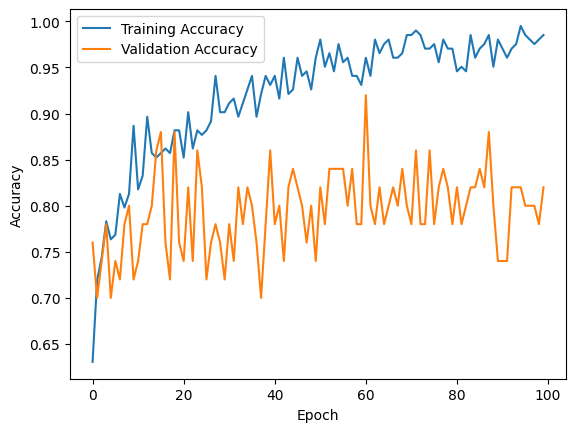

In [55]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

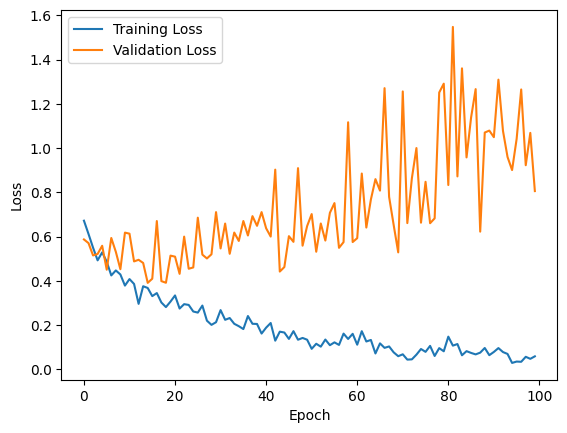

In [56]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training Loss', 'Validation Loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [57]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

In [58]:
loss, acc = cnn.evaluate(validation_set)

print("Validation Accuracy:", acc*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8200 - loss: 1.0431
Validation Accuracy: 81.99999928474426
